1. Implemente el detector de bordes de Prewitt en una funci ́on que retorne una
imagen binaria con los bordes detectados.

2. Estudie detalladamente los par ́ametros de la implementaci ́on de Sobel de OpenCV.
Realice un programa que aplique Sobel y le permita variar par ́ametros:

- el tipo de dato del resultado (CV 8U; CV 64F)
- derivadas en x e y (dx, dy)
- el tama ̃no de la m ́ascara (ksize)

Cargue la imagen patron bordes.jpg y obtenga los siguientes resultados:
- perfiles de intensidad que le permitan intuir los resultados posteriores
- los bordes en direcci ́on x
- los bordes en direcci ́on y
- los bordes en todos los sentidos
- los bordes en todos los sentidos variando ddepth
- los bordes en todos los sentidos variando el par ́ametro ksize (3, 5 y 7)
- los bordes utilizando la apertura de Scharr (ksize = FILTER SCHARR (-1)))
Repita con una imagen real, analice los resultados y comparelos.

3. Estudie la implementaci ́on del detector de bordes Laplacian (2da. derivada) y
analice su uso variando la talla del filtro.

4. Implemente un programa que le permita evaluar el comportamiento del detector
de bordes de Canny, mientras varia sus par ́ametros de forma interactiva.
Eval ́ue los resultados al cambiar el par ́ametro L2gradient.

5. Cargue la imagen ’mosquito.jpg’ y genere versiones con ruido impulsivo uni-
modal (variando el gris en que aparece) y con ruido gaussiano (μ = 0) para
distintos valores de desv ́ıo est ́andar.
Aplique los distintos detectores de bordes a cada caso y compare los desempe ̃nos.
Algunas preguntas de gu ́ıa : ¿En qu ́e zonas (debido a qu ́e) funciona mejor y en
cuales no?, ¿Qu ́e sucede con el ruido?, ¿Con qu ́e tipo de im ́agenes sacar ́ıa mejor
provecho de los m ́etodos?, ¿Qu ́e tipo de preprocesamientos, de los que ya conoce,
se le ocurren que ser ́ıan  ́utiles?, etc.
2

[Opcional ]: implemente una funci ́on que le permita realizar la conexi ́on local de
bordes, a partir de las condiciones:
|∇f(x,y) −∇f(x0,y0) |≤T1
|α(x,y) −α(x0,y0) |< T2


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Parte 1
implementar prewitt

In [2]:
def get_prewit(img, umbral):
    #primero detectara horizontales y luego verticales
    img_float = img.astype(float)

    horizontal_mask = np.array([
        [-1,-1,-1],
        [0,0,0],
        [1,1,1]
    ])
    vertical_mask = np.array([
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]
    ])
    #ahora le aplicamos ambos filtros a la imagen.
    #rotamos las matrices para hacer la convolucion
    h_conv = np.flip(horizontal_mask)
    v_conv = np.flip(vertical_mask)
    print(h_conv)
    print(v_conv)

    gx = cv2.filter2D(img_float, -1, h_conv)
    gy = cv2.filter2D(img_float, -1, v_conv)

    magnitud = np.sqrt(gx**2 + gy**2)
    magnitud_norm = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    _, binaria = cv2.threshold(magnitud_norm, umbral, 255, cv2.THRESH_BINARY)

    return binaria



[[ 1  1  1]
 [ 0  0  0]
 [-1 -1 -1]]
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]


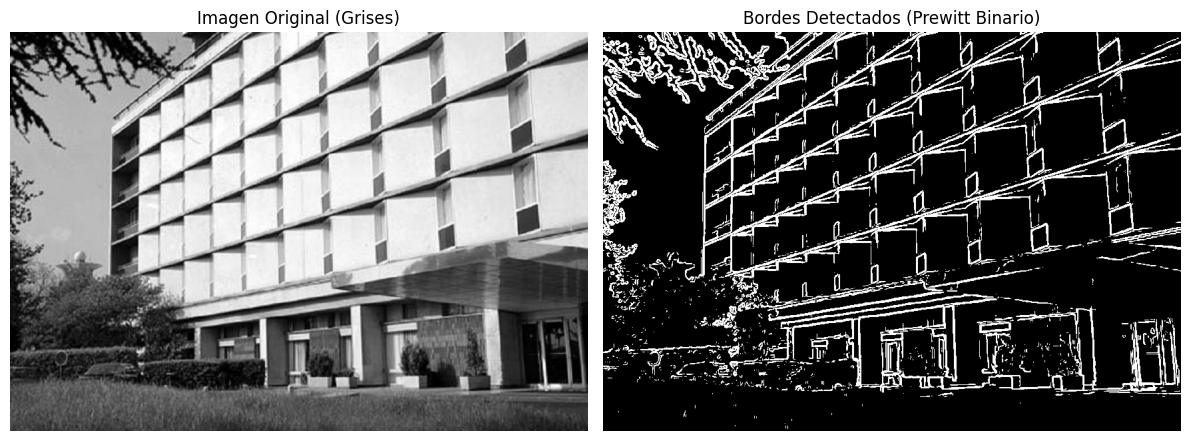

In [3]:
img = cv2.imread("../Imagenes_cursado/building.jpg", cv2.IMREAD_GRAYSCALE)
resultado_bordes = get_prewit(img, umbral=50)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Imagen Original (Grises)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(resultado_bordes, cmap='gray')
plt.title('Bordes Detectados (Prewitt Binario)')
plt.axis('off')

plt.tight_layout()
plt.show()


# parte 2
Sobel: parametros
- src
- ddepth: tipo de dato
- dx
- dy
- ksize

sobel_x
sobel_y

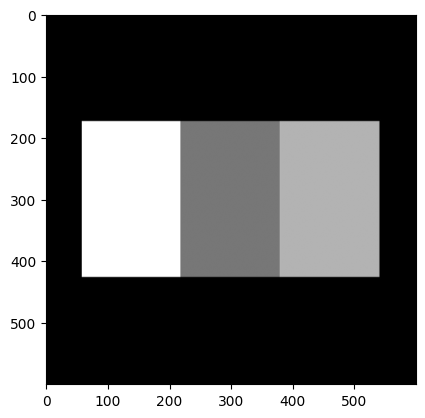

In [4]:
img = cv2.imread("../Imagenes_cursado/patron_bordes.jpg", cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap="gray")
plt.show()



Analizamos perfiles horizontales y verticales

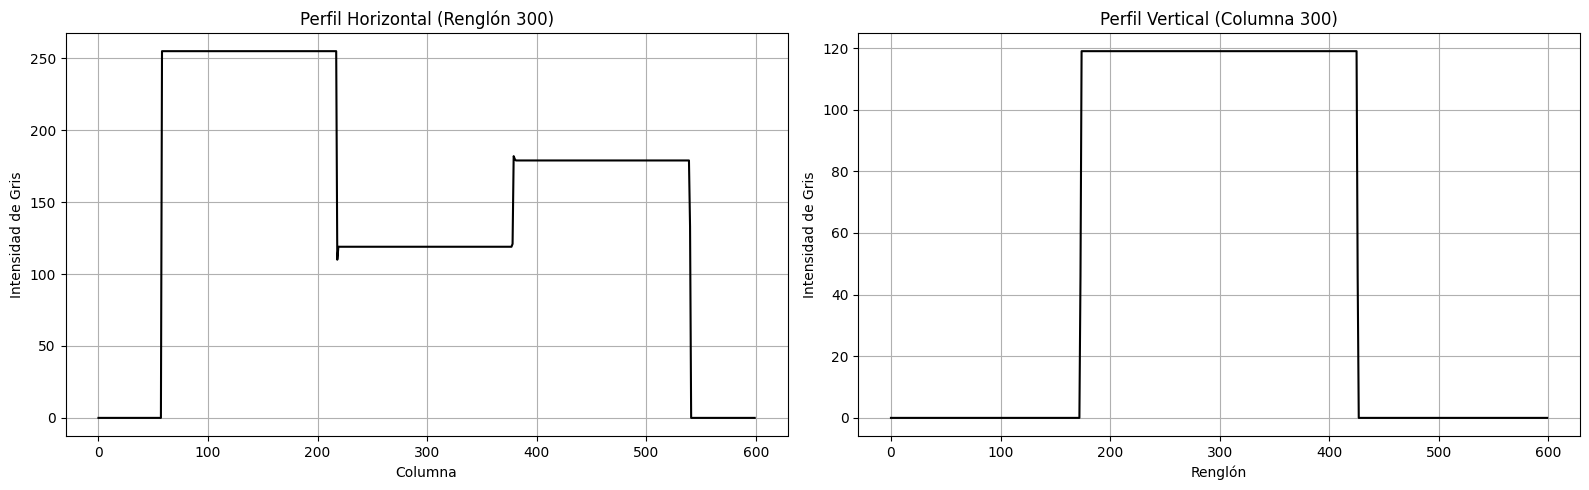

In [5]:
perfil_horizontal = img[300, :]
perfil_vertical = img[:, 300]
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

axs[0].plot(perfil_horizontal, color='black')
axs[0].set_title('Perfil Horizontal (Renglón 300)')
axs[0].set_xlabel('Columna')
axs[0].set_ylabel('Intensidad de Gris')
axs[0].grid(True)

axs[1].plot(perfil_vertical, color='black')
axs[1].set_title('Perfil Vertical (Columna 300)')
axs[1].set_xlabel('Renglón')
axs[1].set_ylabel('Intensidad de Gris')
axs[1].grid(True)

plt.tight_layout()
plt.show()

Esperariamos que el sobel de:
- perfil horizontal: 4 valores distintos
- perfil vertical: 2 niveles

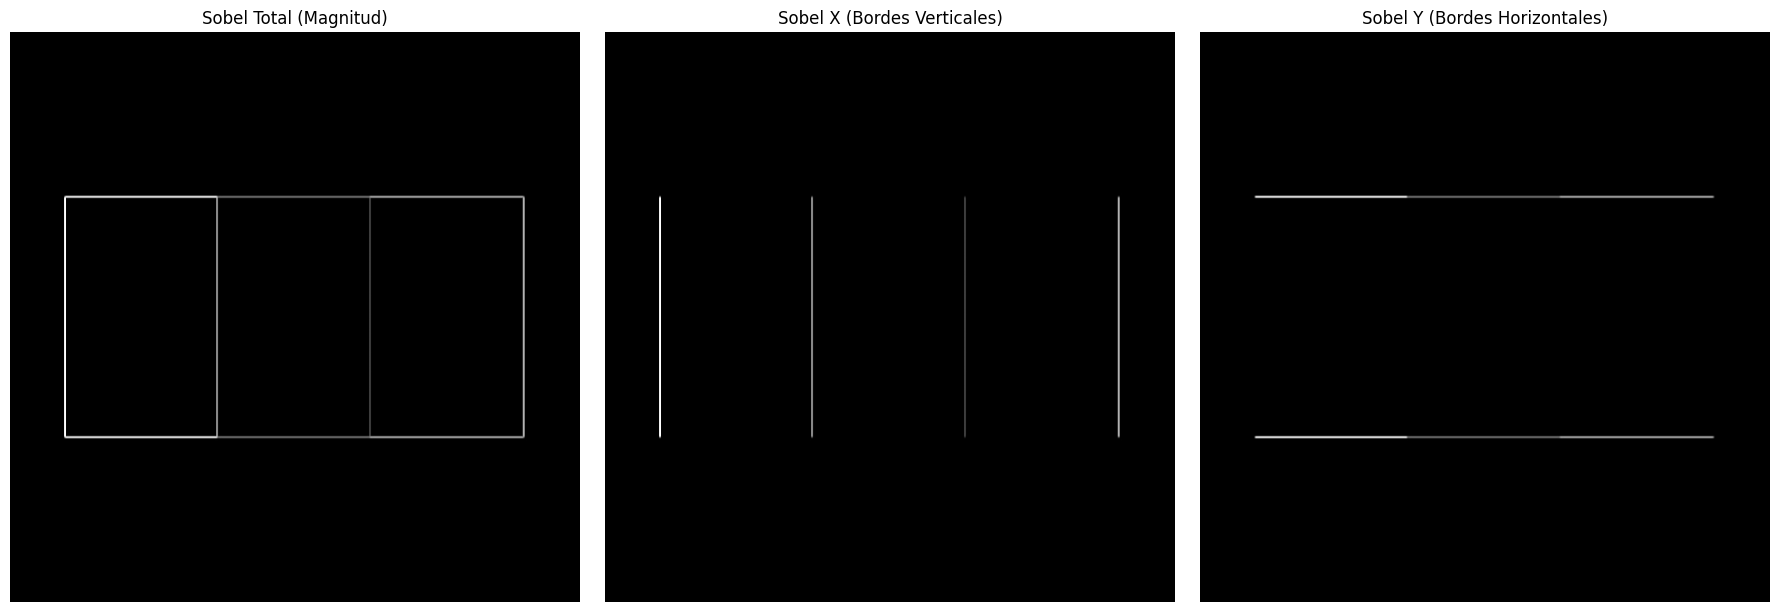

In [6]:
sobelx_raw = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely_raw = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

sobel_total = np.sqrt(sobelx_raw**2 + sobely_raw**2)

sobelx = np.absolute(sobelx_raw)
sobely = np.absolute(sobely_raw)


fig, axs = plt.subplots(1, 3, figsize=(18, 6))


axs[0].imshow(sobel_total, cmap='gray')
axs[0].set_title('Sobel Total (Magnitud)')
axs[0].axis('off')

axs[1].imshow(sobelx, cmap='gray')
axs[1].set_title('Sobel X (Bordes Verticales)')
axs[1].axis('off')

axs[2].imshow(sobely, cmap='gray')
axs[2].set_title('Sobel Y (Bordes Horizontales)')
axs[2].axis('off')

plt.tight_layout()
plt.show()

Analisis de los parametros de la funcion

In [7]:
from ipywidgets import interact, widgets

def interact_sobel_simple(imagen, ddepth_name, ksize, scharr):
    depth_map = {
        "CV_8U": cv2.CV_8U,
        "CV_16S": cv2.CV_16S,
        "CV_32F": cv2.CV_32F,
        "CV_64F": cv2.CV_64F
    }
    selected_depth = depth_map[ddepth_name]

    actual_ksize = -1 if scharr else ksize

    sobelx_raw = cv2.Sobel(imagen, selected_depth, 1, 0, ksize=actual_ksize)
    sobely_raw = cv2.Sobel(imagen, selected_depth, 0, 1, ksize=actual_ksize)

    sobelx = np.absolute(sobelx_raw.astype(float))
    sobely = np.absolute(sobely_raw.astype(float))
    sobel_total = np.sqrt(sobelx**2 + sobely**2)

    fig, axs = plt.subplots(1, 3, figsize=(20, 7))

    axs[0].imshow(sobelx, cmap='gray')
    axs[0].set_title('Sobel X (Verticales)')
    axs[0].axis('off')

    axs[1].imshow(sobely, cmap='gray')
    axs[1].set_title('Sobel Y (Horizontales)')
    axs[1].axis('off')

    axs[2].imshow(sobel_total, cmap='gray')
    axs[2].set_title('Sobel Total (Magnitud)')
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()




In [8]:
img = cv2.imread("../Imagenes_cursado/building.jpg", cv2.IMREAD_GRAYSCALE)

interact(
    interact_sobel_simple, 
    imagen=widgets.fixed(img), 
    ddepth_name=widgets.Dropdown(
        options=["CV_8U", "CV_16S", "CV_32F", "CV_64F"],
        value="CV_64F",
        description="ddepth:"
    ),
    ksize=widgets.SelectionSlider(
        options=[3, 5, 7],
        value=3,
        description="ksize:"
    ),
    scharr=widgets.Checkbox(
        value=False,
        description="Usar Scharr (-1)"
    )
)

interactive(children=(Dropdown(description='ddepth:', index=3, options=('CV_8U', 'CV_16S', 'CV_32F', 'CV_64F')…

<function __main__.interact_sobel_simple(imagen, ddepth_name, ksize, scharr)>

Por lo que observe:
- kernel size: a mayor kernel, mayores el tamaño, mas engrosamiento de los bordes
- ddepth (profundidad): 8U se pierde informacion, no admite numeros negativos y cuando el gradiente pasa de blanco a negro, da negativo y se trunca, desaparecen los bordes.
- scharr: 

img = 
interact(
    interact_sobel_simple, 
    imagen=widgets.fixed(img), 
    ddepth_name=widgets.Dropdown(
        options=["CV_8U", "CV_16S", "CV_32F", "CV_64F"],
        value="CV_64F",
        description="ddepth:"
    ),
    ksize=widgets.SelectionSlider(
        options=[3, 5, 7],
        value=3,
        description="ksize:"
    ),
    scharr=widgets.Checkbox(
        value=False,
        description="Usar Scharr (-1)"
    )
)

# parte 3
Implementacion de laplaciano

In [9]:
def get_laplaciano(img, umbral=50):
    img_float = img.astype(float)
    
    laplacian_mask = np.array([
        [0,  1, 0],
        [1, -4, 1],
        [0,  1, 0]
    ])
    
    l_conv = np.flip(laplacian_mask)
    
    laplace_raw = cv2.filter2D(img_float, cv2.CV_64F, l_conv)
    laplace_abs = np.absolute(laplace_raw)
    
    laplace_norm = cv2.normalize(laplace_abs, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    _, binaria = cv2.threshold(laplace_norm, umbral, 255, cv2.THRESH_BINARY)
    
    return laplace_norm, binaria

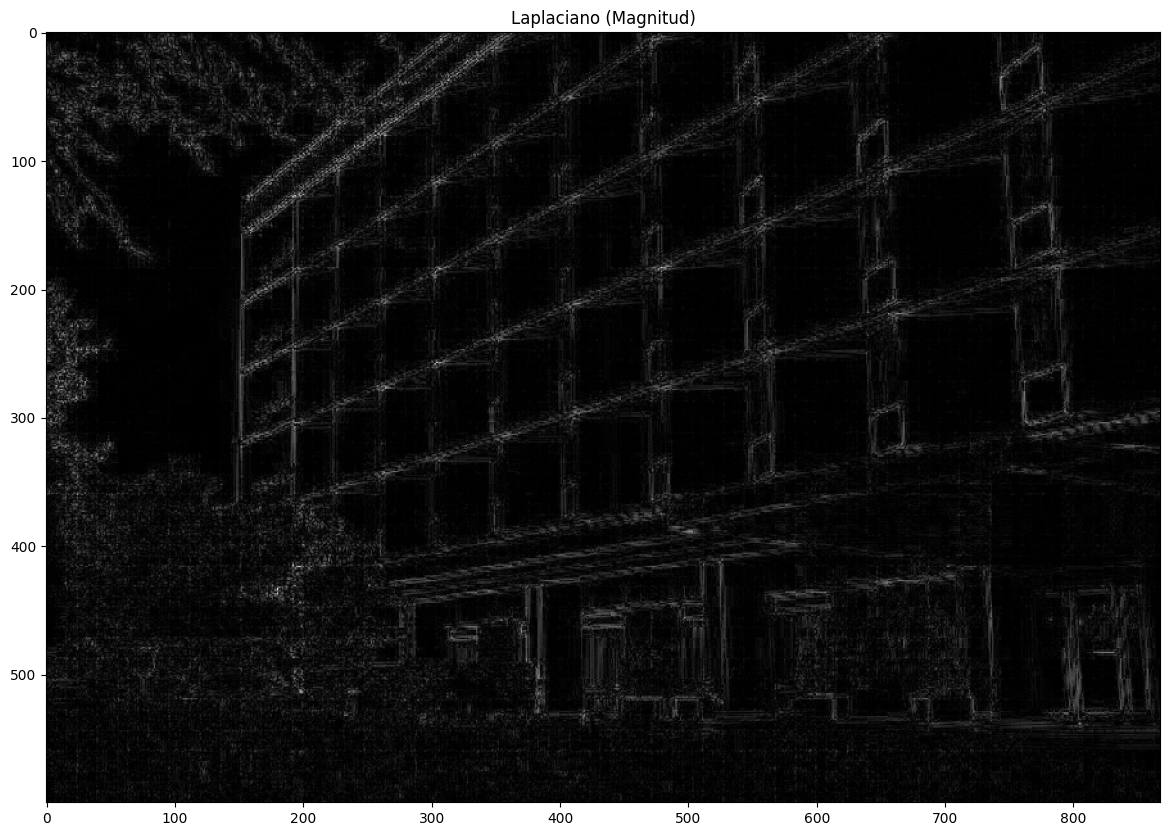

In [10]:
img = cv2.imread("../Imagenes_cursado/building.jpg", cv2.IMREAD_GRAYSCALE)

laplace_img, laplace_bin = get_laplaciano(img, umbral=30)


plt.figure(figsize=(15,10))
plt.imshow(laplace_img, cmap='gray')
plt.title('Laplaciano (Magnitud)')
plt.show()

vemos mucho ruido, lineas dobles. No sirve mucho

# parte 4
Ejercicio canny

Lo que hace el algoritmo es:
- Reduccion de ruido a la imagen original con un filtro gassiano
- Calcula el gradiente, cambios en la intensidad. APlica Sobel para obtener la magnitud de los gradientes
- Supresion de no maximos: Se ve mas limpio que sobel porque filtra pixeles. Recorre la iamgen en la dirección del gradiente y verifica si el pixel actual es el maximo local. Si no es el mas fuerte, lo pone en cero (no es maximo). Por ende los bordes tienen 1 pixel de ancho pero con intensidades diferentes todavia

Umbralizacion: Canny identifica:
- Bordes fuertes: PIxeles con gradiente mayor al umbral alto se aceptan automaticamente
- bordes debiles: pixeles con gradiente entre el umbral bajo y el alto
- descarte: pixeles por debajo del umbral bajo. Solo se conectan si acompañan a un borde ferte (si lo toca fisicamente)

l2 gradiant es para ver si la calcula exacta a la norma o la aproxima con los valores absolutos


In [11]:
def interact_canny(img,umbral_bajo, umbral_alto, usar_l2):
    bordes = cv2.Canny(
        img, 
        threshold1=umbral_bajo, 
        threshold2=umbral_alto, 
        L2gradient=usar_l2
    )

    # Visualización
    plt.figure(figsize=(12, 8))
    plt.imshow(bordes, cmap='gray')
    plt.title(f'Canny | Umbrales: ({umbral_bajo}, {umbral_alto}) | L2gradient: {usar_l2}')
    plt.axis('off')
    plt.show()

interact(
    interact_canny, 
    img=widgets.fixed(img), 
    umbral_bajo=widgets.IntSlider(
        min=0, max=500, step=1, value=50, 
        description="Umbral Bajo:"
    ),
    umbral_alto=widgets.IntSlider(
        min=0, max=500, step=1, value=150, 
        description="Umbral Alto:"
    ),
    usar_l2=widgets.Checkbox(
        value=False, 
        description="L2gradient (Norma L2)"
    )
)

interactive(children=(IntSlider(value=50, description='Umbral Bajo:', max=500), IntSlider(value=150, descripti…

<function __main__.interact_canny(img, umbral_bajo, umbral_alto, usar_l2)>

# parte 5
Ejercicio mosquito

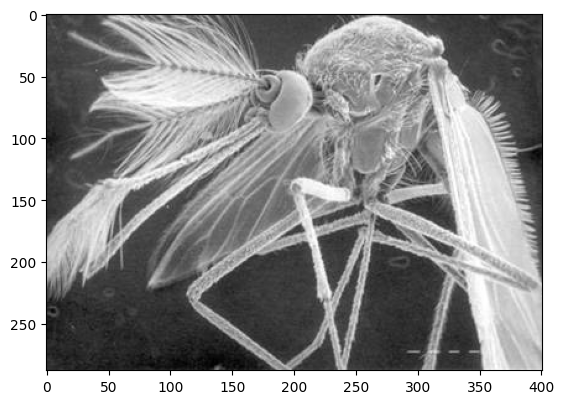

In [12]:
img = cv2.imread("../Imagenes_cursado/mosquito.jpg", cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap = "gray")

In [13]:
def agregar_ruido_unimodal(imagen, probabilidad, valor_gris):

    copia = imagen.copy()
    rdm = np.random.rand(*imagen.shape)
    copia[rdm < probabilidad] = valor_gris
    return copia

def agregar_ruido_gaussiano(imagen, sigma):

    # Generar el ruido con media (mu) = 0
    gauss = np.random.normal(0, sigma, imagen.shape)
    # Sumar a la imagen y asegurar que los valores sigan en el rango [0, 255]
    img_ruidosa = imagen.astype(float) + gauss
    img_ruidosa = np.clip(img_ruidosa, 0, 255).astype(np.uint8)
    return img_ruidosa

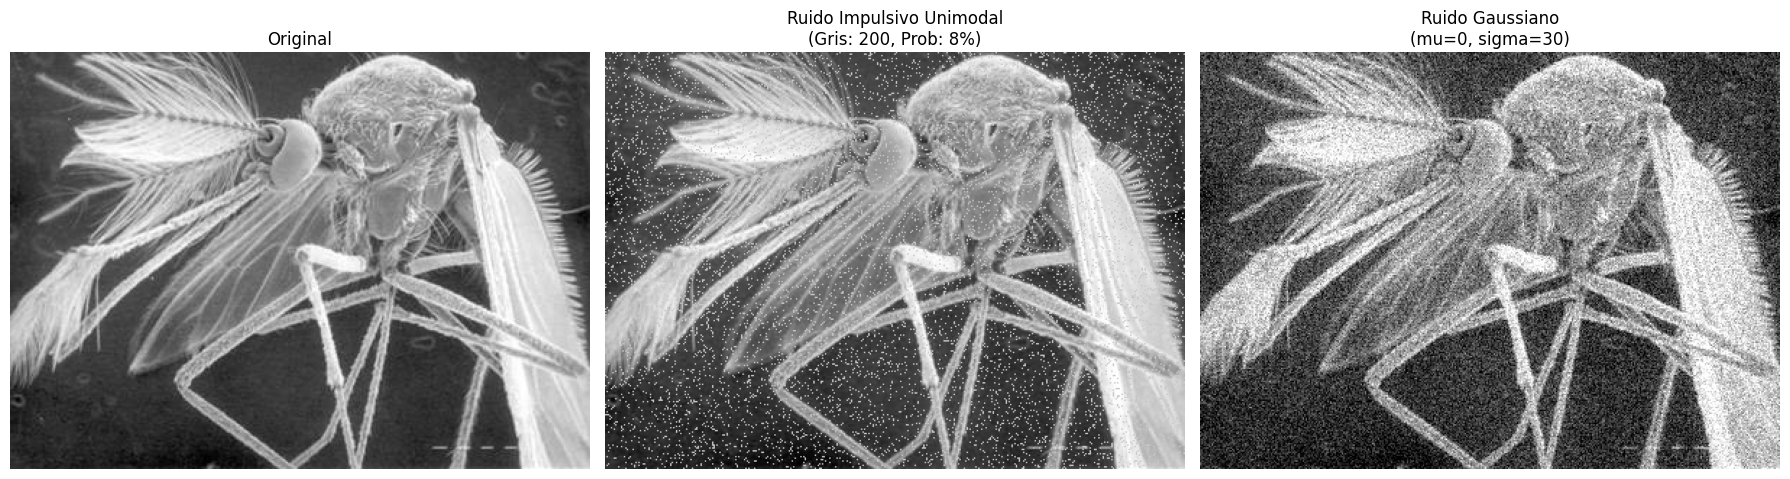

In [14]:
img_unimodal = agregar_ruido_unimodal(img, probabilidad=0.08, valor_gris=200)
img_gaussiana = agregar_ruido_gaussiano(img, sigma=30)

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

axs[0].imshow(img, cmap='gray')
axs[0].set_title('Original')
axs[0].axis('off')

axs[1].imshow(img_unimodal, cmap='gray')
axs[1].set_title('Ruido Impulsivo Unimodal\n(Gris: 200, Prob: 8%)')
axs[1].axis('off')

axs[2].imshow(img_gaussiana, cmap='gray')
axs[2].set_title('Ruido Gaussiano\n(mu=0, sigma=30)')
axs[2].axis('off')

plt.tight_layout()
plt.show()

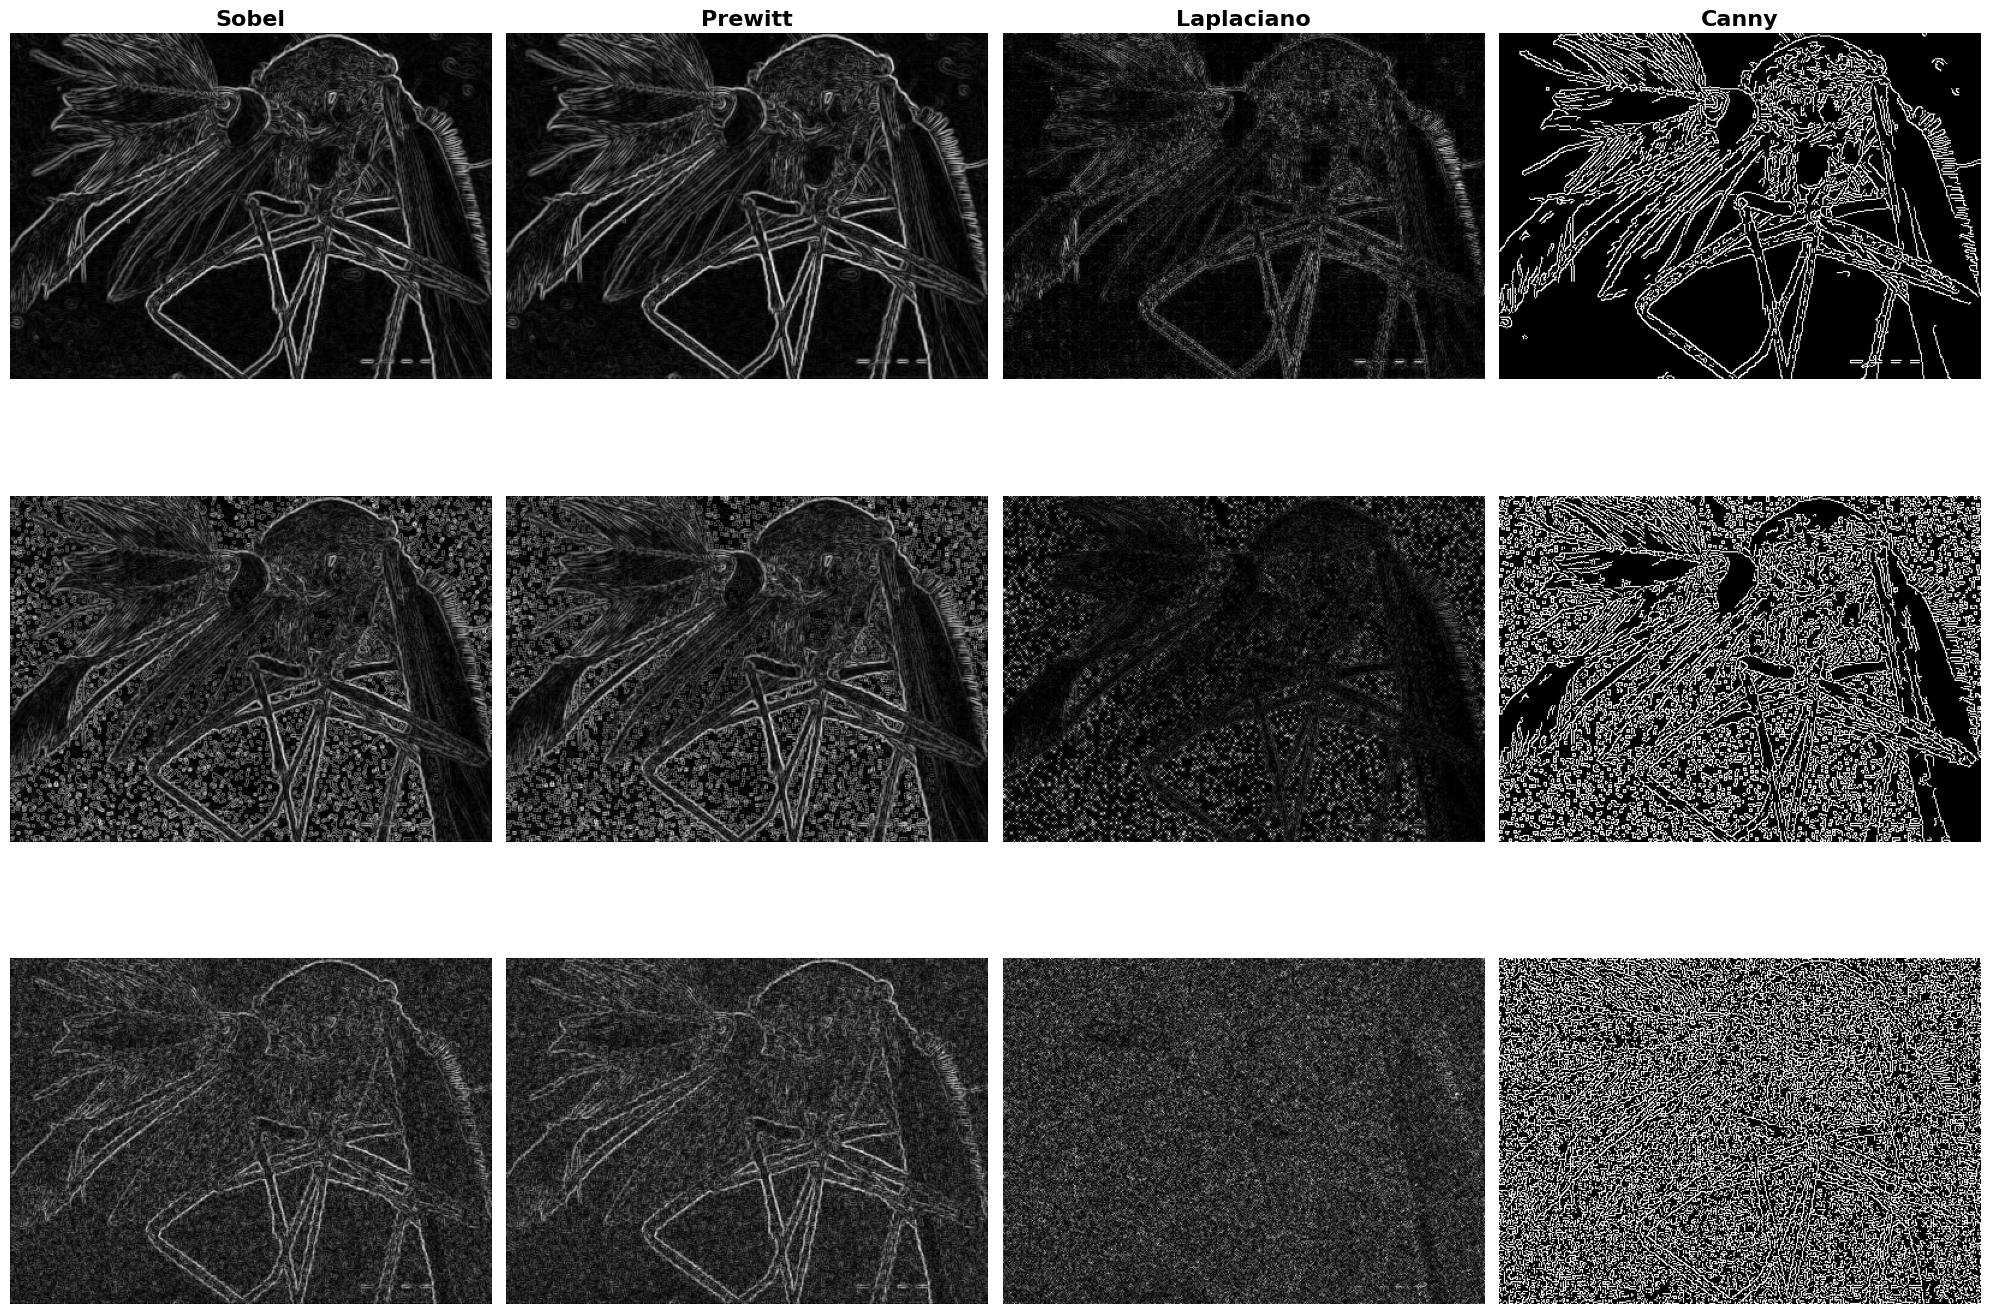

In [15]:
#aplicamos detectores de bordes
imagenes_base = [img, img_unimodal, img_gaussiana]
nombres_filas = ["Original", "Impulsivo", "Gaussiano"]

fig, axs = plt.subplots(3, 4, figsize=(20, 15))

for i, base in enumerate(imagenes_base):

    sx = cv2.Sobel(base, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(base, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.sqrt(sx**2 + sy**2)
    
    px = cv2.filter2D(base.astype(float), cv2.CV_64F, np.array([[-1,0,1],[-1,0,1],[-1,0,1]]))
    py = cv2.filter2D(base.astype(float), cv2.CV_64F, np.array([[-1,-1,-1],[0,0,0],[1,1,1]]))
    prewitt = np.sqrt(px**2 + py**2)
    

    laplace = cv2.Laplacian(base, cv2.CV_64F, ksize=3)
    laplace = np.absolute(laplace)
    

    canny = cv2.Canny(base, 100, 220)

    detectores = [sobel, prewitt, laplace, canny]
    titulos = ["Sobel", "Prewitt", "Laplaciano", "Canny"]
    
    for j, det in enumerate(detectores):
        axs[i, j].imshow(det, cmap='gray')
        if i == 0:
            axs[i, j].set_title(titulos[j], fontsize=16, fontweight='bold')
        if j == 0:
            axs[i, j].set_ylabel(nombres_filas[i], fontsize=16, fontweight='bold')
        axs[i, j].axis('off')

plt.tight_layout()
plt.show()

todos los filtrtos muy sensible al ruido. El gaussiano el peor de todos.
Habria que hacer un preprocesamiento dle mismo para quitar el ruido.


# parte 6

hecho entero con ia, quiero ver los efectos nomas

In [16]:
import numpy as np
import cv2

def conectar_bordes_local(mag, ang, T1, T2):
    """
    Realiza la conexión local de bordes basándose en magnitud y dirección.
    
    Parámetros:
    - mag: Matriz de magnitud del gradiente.
    - ang: Matriz de ángulos del gradiente (en radianes o grados).
    - T1: Umbral de diferencia de magnitud.
    - T2: Umbral de diferencia de ángulo.
    """
    filas, columnas = mag.shape
    img_vinculada = np.zeros((filas, columnas), dtype=np.uint8)
    
    # Definimos la vecindad (8-conectividad)
    offsets = [(-1, -1), (-1, 0), (-1, 1), 
               (0, -1),           (0, 1), 
               (1, -1),  (1, 0),  (1, 1)]
    
    for i in range(1, filas - 1):
        for j in range(1, columnas - 1):
            # Gradiente en el punto central (x0, y0)
            mag_0 = mag[i, j]
            ang_0 = ang[i, j]
            
            # Solo intentamos conectar si el punto actual tiene algo de magnitud
            if mag_0 > 0:
                for di, dj in offsets:
                    ni, nj = i + di, j + dj
                    
                    mag_n = mag[ni, nj]
                    ang_n = ang[ni, nj]
                    
                    # Condición 1: Diferencia de magnitud <= T1
                    cond_mag = np.abs(mag_0 - mag_n) <= T1
                    
                    # Condición 2: Diferencia de ángulo < T2
                    # Nota: La diferencia de ángulo debe manejar la periodicidad (0-360)
                    diff_ang = np.abs(ang_0 - ang_n)
                    cond_ang = diff_ang < T2 or (360 - diff_ang) < T2 # Para grados
                    
                    if cond_mag and cond_ang:
                        # Si cumple ambas, marcamos el píxel como parte de un borde conectado
                        img_vinculada[i, j] = 255
                        img_vinculada[ni, nj] = 255
                        
    return img_vinculada

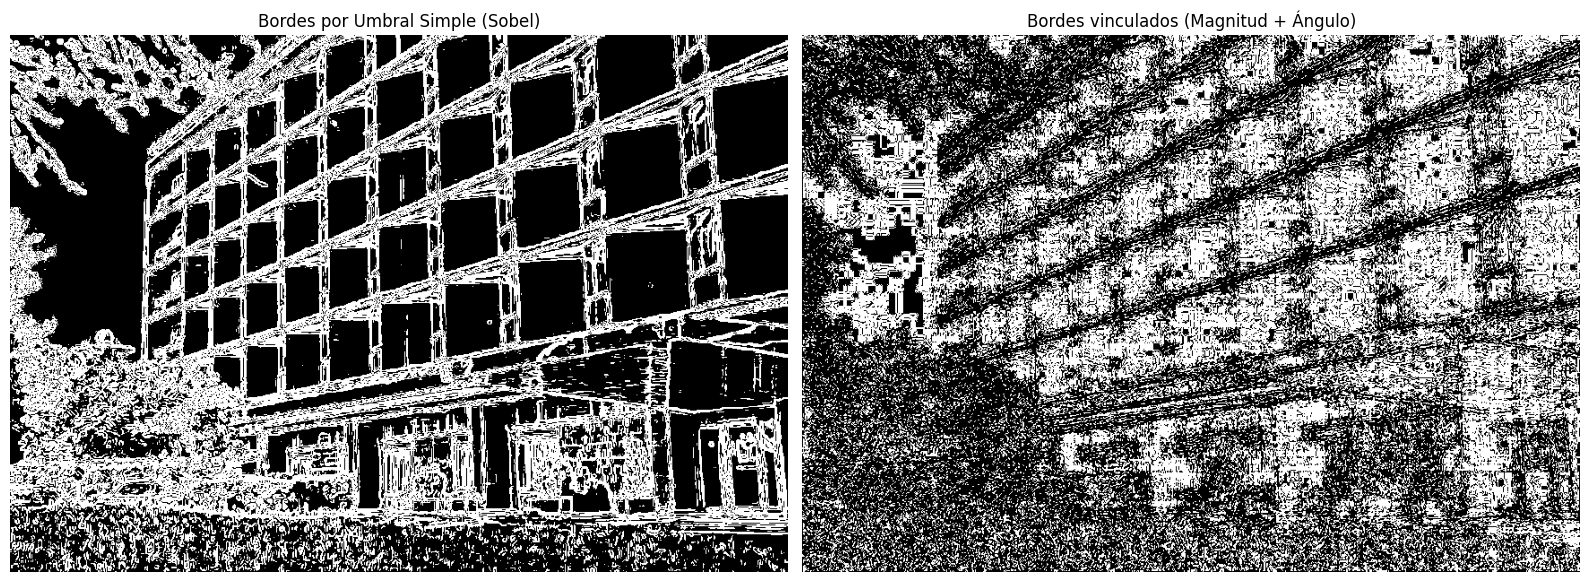

In [17]:
img = cv2.imread("../Imagenes_cursado/building.jpg", cv2.IMREAD_GRAYSCALE)

# 1. Calcular Magnitud y Ángulo (Necesarios para la función)
gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

magnitud = np.sqrt(gx**2 + gy**2)
# arctan2 nos da el ángulo en radianes, lo pasamos a grados para T2
angulo = np.arctan2(gy, gx) * (180 / np.pi) 

# 2. Aplicar tu nueva función
# T1: Tolerancia de intensidad (si la diferencia de gris es > T1, no se conectan)
# T2: Tolerancia de ángulo (si la dirección cambia > T2 grados, no se conectan)
bordes_vinculados = conectar_bordes_local(magnitud, angulo, T1=5, T2=15)

# 3. Visualización comparativa
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

# Resultado de Sobel normal (binarizado para comparar "peras con peras")
_, sobel_umbral = cv2.threshold(magnitud.astype(np.uint8), 50, 255, cv2.THRESH_BINARY)
axs[0].imshow(sobel_umbral, cmap='gray')
axs[0].set_title('Bordes por Umbral Simple (Sobel)')
axs[0].axis('off')

# Resultado de tu función de conexión
axs[1].imshow(bordes_vinculados, cmap='gray')
axs[1].set_title('Bordes vinculados (Magnitud + Ángulo)')
axs[1].axis('off')

plt.tight_layout()
plt.show()

impactado :0